# Chapter 4: Reservoir Engineering and Inflow Performance

This notebook demonstrates reservoir engineering concepts relevant to production optimization:
- Inflow Performance Relationship (IPR) curves using PI and Vogel models
- Gas-Oil Ratio behavior during pressure depletion
- Fluid density variation with depth (geothermal gradient)
- Relative permeability curves using the Corey model

We use NeqSim to model reservoir fluids and compute thermodynamic properties at various conditions.

In [1]:
# Execute against the selected, compiled NeqSim source checkout.
import os
import sys
from pathlib import Path
import numpy as np
import matplotlib
matplotlib.use("Agg")
import matplotlib.pyplot as plt
import jpype

if not os.environ.get("NEQSIM_PROJECT_ROOT"):
    raise RuntimeError("Set NEQSIM_PROJECT_ROOT to the NeqSim source checkout before running.")
PROJECT_ROOT = Path(os.environ["NEQSIM_PROJECT_ROOT"]).resolve()
if not (PROJECT_ROOT / "devtools" / "neqsim_dev_setup.py").exists():
    raise RuntimeError("NEQSIM_PROJECT_ROOT must contain devtools/neqsim_dev_setup.py.")
sys.path.insert(0, str(PROJECT_ROOT / "devtools"))
from neqsim_dev_setup import neqsim_init, neqsim_classes
ns = neqsim_classes(neqsim_init(project_root=PROJECT_ROOT, recompile=False, verbose=False))
jneqsim = jpype.JPackage("neqsim")
NEQSIM_MODE = "devtools"
NOTEBOOK_PATH = Path(globals().get("__vsc_ipynb_file__", Path.cwd() / "ch04_reservoir_figures.ipynb")).resolve()
BOOK_ROOT = NOTEBOOK_PATH.parents[3]
FIGURES_DIR = NOTEBOOK_PATH.parent.parent / "figures"
FIGURES_DIR.mkdir(exist_ok=True)
sys.path.insert(0, str(BOOK_ROOT / "devtools"))
from book_figure_tools import configure_figures, export_figure_summary
configure_figures()
print(f"NeqSim source: {PROJECT_ROOT}; Python: {sys.executable}")

# Named NeqSim class bindings used throughout the chapter.
SystemSrkEos = jneqsim.thermo.system.SystemSrkEos
SystemPrEos = jneqsim.thermo.system.SystemPrEos
SystemSrkCPAstatoil = jneqsim.thermo.system.SystemSrkCPAstatoil
ThermodynamicOperations = jneqsim.thermodynamicoperations.ThermodynamicOperations
Stream = jneqsim.process.equipment.stream.Stream
Separator = jneqsim.process.equipment.separator.Separator
ThreePhaseSeparator = jneqsim.process.equipment.separator.ThreePhaseSeparator
Compressor = jneqsim.process.equipment.compressor.Compressor
Cooler = jneqsim.process.equipment.heatexchanger.Cooler
Heater = jneqsim.process.equipment.heatexchanger.Heater
HeatExchanger = jneqsim.process.equipment.heatexchanger.HeatExchanger
Mixer = jneqsim.process.equipment.mixer.Mixer
Splitter = jneqsim.process.equipment.splitter.Splitter
ThrottlingValve = jneqsim.process.equipment.valve.ThrottlingValve
Pump = jneqsim.process.equipment.pump.Pump
Expander = jneqsim.process.equipment.expander.Expander
Recycle = jneqsim.process.equipment.util.Recycle
ProcessSystem = jneqsim.process.processmodel.ProcessSystem

# Physical verification uses the same model state, source and interpreter.
sys.path.insert(0, str(BOOK_ROOT / "verification" / "scientific_revision"))
from notebook_physics_checks import PhysicsChecks
_physics = PhysicsChecks(NOTEBOOK_PATH)


All NeqSim classes imported OK
NeqSim source: C:\Users\solbraa\OneDrive - NTNU\Documents\ChatGPT\NeqSim; Python: C:\Users\solbraa\.cache\codex-runtimes\codex-primary-runtime\dependencies\python\python.exe


In [2]:
import numpy as np
import matplotlib.pyplot as plt

# NeqSim class imports

plt.rcParams.update({'font.size': 12, 'figure.figsize': (10, 7)})


## Create Reservoir Fluid

We define a gas condensate reservoir fluid at typical reservoir conditions:
- Reservoir temperature: 120 °C (393.15 K)
- Reservoir pressure: 300 bara

In [3]:
# Reservoir conditions
T_res_C = 120.0  # °C
T_res_K = 273.15 + T_res_C  # K
P_res_bara = 300.0  # bara

# Create a gas condensate fluid
fluid = SystemSrkEos(T_res_K, P_res_bara)
fluid.addComponent("nitrogen", 0.5)
fluid.addComponent("CO2", 1.5)
fluid.addComponent("methane", 70.0)
fluid.addComponent("ethane", 8.0)
fluid.addComponent("propane", 5.0)
fluid.addComponent("i-butane", 1.5)
fluid.addComponent("n-butane", 2.0)
fluid.addComponent("i-pentane", 1.0)
fluid.addComponent("n-pentane", 1.0)
fluid.addComponent("n-hexane", 2.0)
fluid.addComponent("n-heptane", 3.0)
fluid.addComponent("n-octane", 2.5)
fluid.addComponent("n-nonane", 1.5)
fluid.addComponent("nC10", 0.5)
fluid.setMixingRule("classic")

# Flash at reservoir conditions
ops = ThermodynamicOperations(fluid)
ops.TPflash()
fluid.initProperties()
assert _physics.state(fluid, 'calculation_cell_4:fluid', candidate=False)

print(f"Reservoir T: {T_res_C:.0f} °C, P: {P_res_bara:.0f} bara")
print(f"Number of phases: {fluid.getNumberOfPhases()}")
print(f"Gas density: {fluid.getPhase('gas').getDensity('kg/m3'):.2f} kg/m3")
print(f"Gas viscosity: {fluid.getPhase('gas').getViscosity('kg/msec'):.6f} kg/(m·s)")


Reservoir T: 120 °C, P: 300 bara
Number of phases: 1
Gas density: 297.50 kg/m3
Gas viscosity: 0.000037 kg/(m·s)


## Figure 1: Inflow Performance Relationship (IPR) Curves

We compare two IPR models commonly used in production engineering:

1. **Productivity Index (PI) model** (linear): $q = J \cdot (P_{res} - P_{wf})$
2. **Vogel model** (for solution-gas drive): $\frac{q}{q_{max}} = 1 - 0.2\frac{P_{wf}}{P_{res}} - 0.8\left(\frac{P_{wf}}{P_{res}}\right)^2$

These models are essential for determining well deliverability and optimal drawdown.

Figure 1 saved.


ch04_reservoir_figures.ipynb:cell6:35: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown


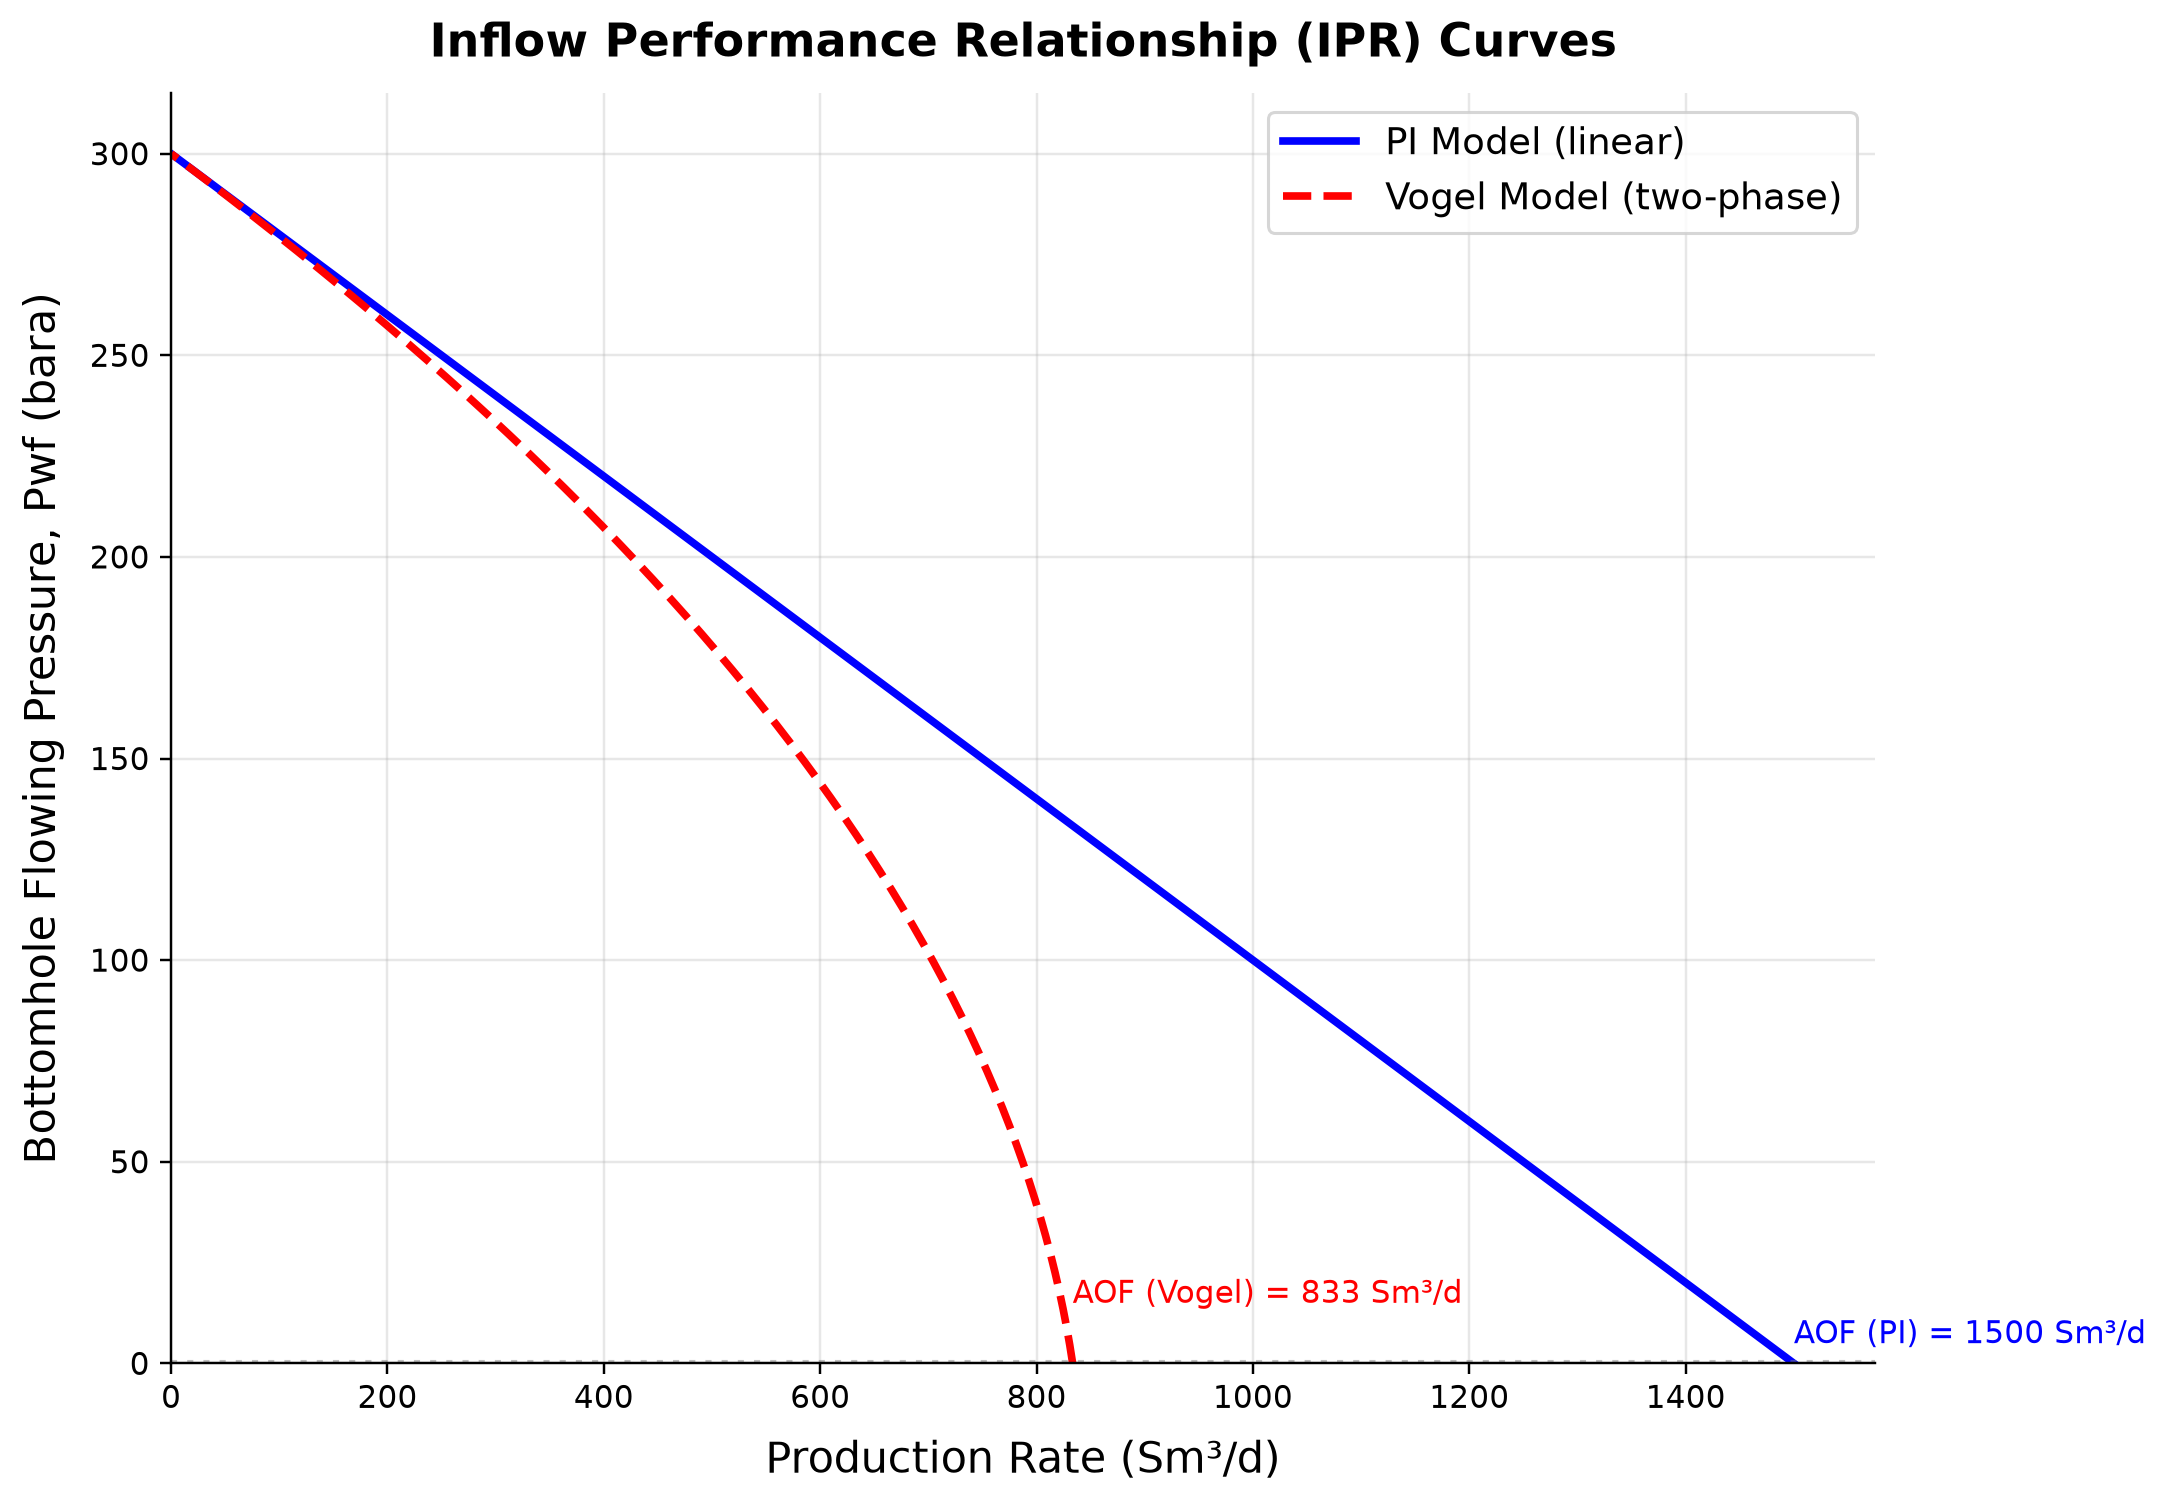

In [4]:
# IPR model parameters
P_res = 300.0  # Reservoir pressure (bara)
PI = 5.0  # Productivity index (Sm3/d/bar)
q_max_vogel = PI * P_res / 1.8  # Maximum rate from Vogel (at Pwf=0)

# Bottomhole flowing pressure range
Pwf = np.linspace(0, P_res, 200)

# PI model (linear)
q_pi = PI * (P_res - Pwf)

# Vogel model (non-linear, two-phase flow)
q_vogel = q_max_vogel * (1.0 - 0.2 * (Pwf / P_res) - 0.8 * (Pwf / P_res)**2)

fig, ax = plt.subplots(figsize=(10, 7))
ax.plot(q_pi, Pwf, 'b-', linewidth=2.5, label='PI Model (linear)')
ax.plot(q_vogel, Pwf, 'r--', linewidth=2.5, label='Vogel Model (two-phase)')

# Mark AOF (Absolute Open Flow)
ax.axhline(y=0, color='gray', linestyle=':', alpha=0.5)
ax.annotate(f'AOF (PI) = {PI * P_res:.0f} Sm³/d', xy=(PI * P_res, 5),
            fontsize=10, color='blue')
ax.annotate(f'AOF (Vogel) = {q_max_vogel:.0f} Sm³/d', xy=(q_max_vogel, 15),
            fontsize=10, color='red')

ax.set_xlabel('Production Rate (Sm³/d)', fontsize=14)
ax.set_ylabel('Bottomhole Flowing Pressure, Pwf (bara)', fontsize=14)
ax.set_title('Inflow Performance Relationship (IPR) Curves', fontsize=15)
ax.legend(fontsize=12, loc='upper right')
ax.grid(True, alpha=0.3)
ax.set_xlim(0, None)
ax.set_ylim(0, P_res * 1.05)
plt.tight_layout()
plt.savefig(FIGURES_DIR / 'ch04_fig01_ipr_curves.png', dpi=220, bbox_inches='tight')
plt.show()
print("Figure 1 saved.")


**Executed-figure discussion.** PI Model (linear): bottomhole flowing pressure, pwf spans 0–300 bara across the plotted cases. Vogel Model (two-phase): bottomhole flowing pressure, pwf spans 0–300 bara across the plotted cases.

An IPR relates liquid or gas deliverability to drawdown; curvature reflects the selected inflow law and reservoir phase behavior. A high zero-backpressure intercept does not establish a producible operating rate because tubing and facility backpressure still have to be satisfied. Calibrate the appropriate inflow law against well tests and intersect it with a verified tubing relationship on the same rate and pressure basis.


## Figure 2: GOR vs Depletion Pressure

As reservoir pressure declines below the dew/bubble point, gas-oil ratio changes significantly.
We use NeqSim to flash the reservoir fluid at progressively lower pressures and compute
the molar GOR (gas phase moles / oil phase moles).

Two-phase GOR domain: 29 of 50 states; remaining single-phase states are not assigned a GOR.
Figure 2 saved.


ch04_reservoir_figures.ipynb:cell8:40: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown


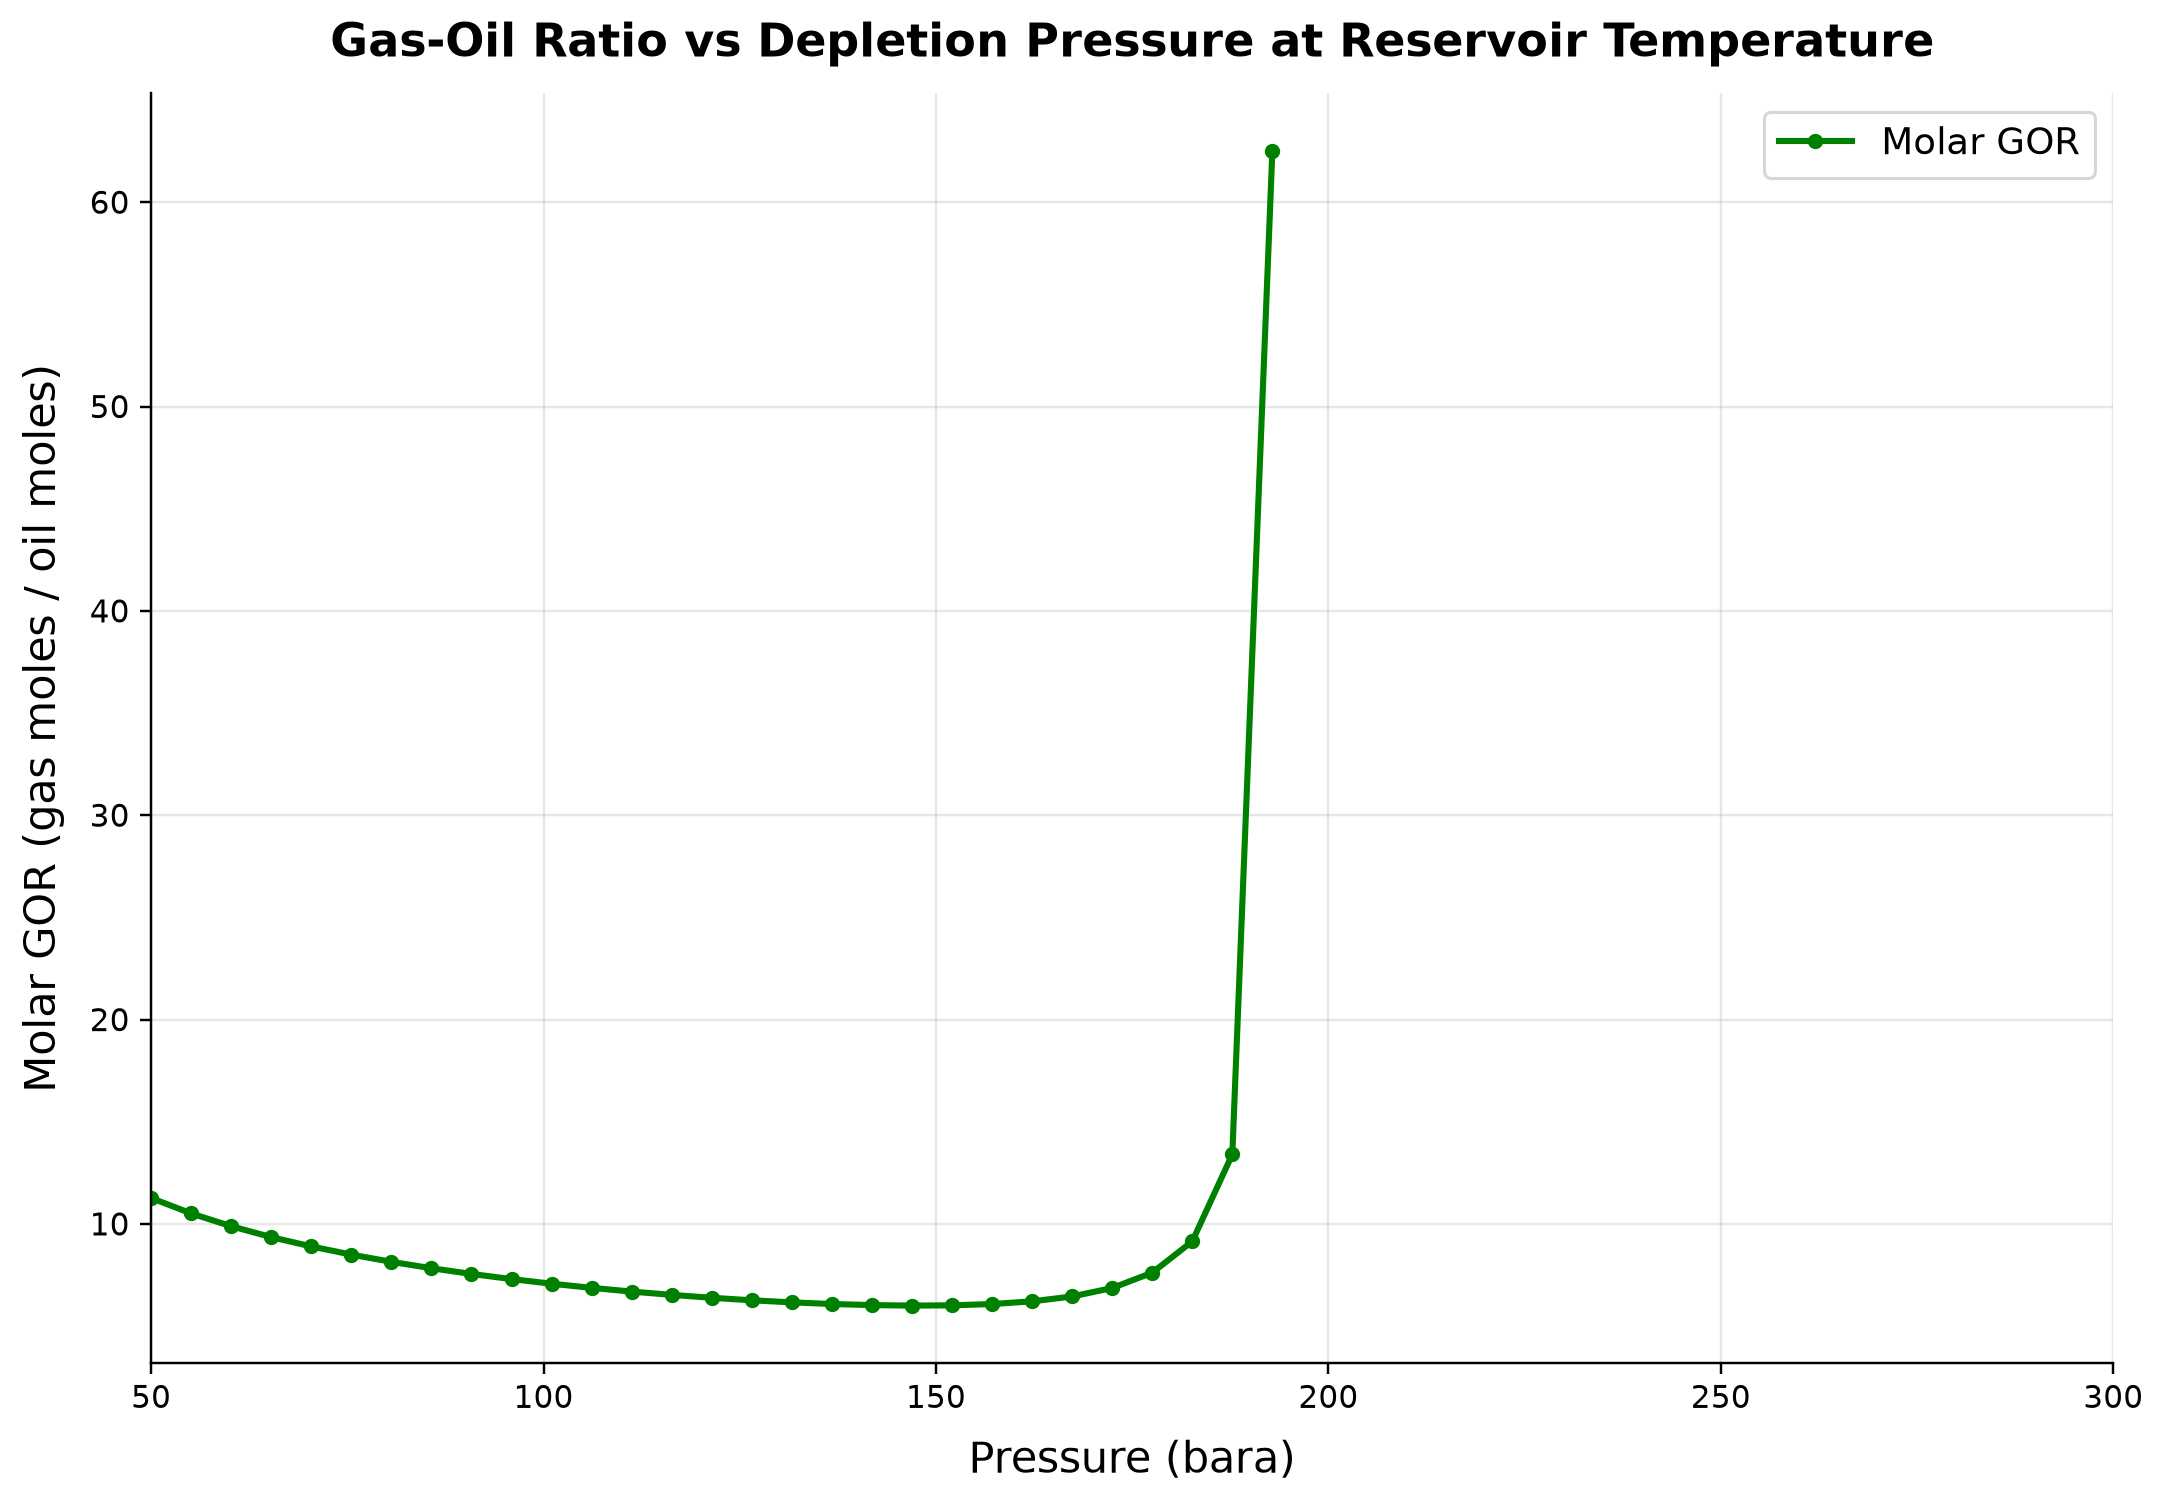

In [5]:
# Pressure depletion: flash at constant T, decreasing P
pressures = np.linspace(50, P_res_bara, 50)
gor_values = []

for p in pressures:
    fluid_dep = fluid.clone()
    fluid_dep.setTemperature(T_res_K)
    fluid_dep.setPressure(float(p))
    ops_dep = ThermodynamicOperations(fluid_dep)
    ops_dep.TPflash()
    fluid_dep.initProperties()
    assert _physics.state(fluid_dep, 'calculation_cell_8:fluid_dep', candidate=False)

    n_phases = fluid_dep.getNumberOfPhases()
    if n_phases > 1:
        gas_moles = fluid_dep.getPhase('gas').getNumberOfMolesInPhase()
        oil_moles = fluid_dep.getPhase('oil').getNumberOfMolesInPhase()
        if oil_moles > 1e-10:
            gor_values.append(gas_moles / oil_moles)
        else:
            gor_values.append(np.nan)
    else:
        # Single phase - either all gas or all liquid
        gor_values.append(np.nan)

# A gas/oil phase ratio is undefined outside the two-phase domain.
finite_gor = np.isfinite(gor_values)
print(f'Two-phase GOR domain: {finite_gor.sum()} of {len(pressures)} states; remaining single-phase states are not assigned a GOR.')
fig, ax = plt.subplots(figsize=(10, 7))
ax.plot(pressures, gor_values, 'g-o', linewidth=2, markersize=4, label='Molar GOR')

ax.set_xlabel('Pressure (bara)', fontsize=14)
ax.set_ylabel('Molar GOR (gas moles / oil moles)', fontsize=14)
ax.set_title('Gas-Oil Ratio vs Depletion Pressure at Reservoir Temperature', fontsize=15)
ax.legend(fontsize=12)
ax.grid(True, alpha=0.3)
ax.set_xlim(pressures[0], pressures[-1])
plt.tight_layout()
plt.savefig(FIGURES_DIR / 'ch04_fig02_gor_vs_pressure.png', dpi=220, bbox_inches='tight')
plt.show()
print("Figure 2 saved.")


**Executed-figure discussion.** Molar GOR spans 6.001–62.51 gas moles / oil moles across the plotted cases. Gaps retain undefined phase quantities or hydraulic states that fail the stated operating boundary; they are not interpolated.

As pressure falls, dissolved light components evolve into a gas phase and change the gas and liquid volumes. Gas-handling demand can increase relative to oil rate during depletion; a static initial GOR can therefore understate future bottlenecks. Distinguish fixed-composition flashes from depletion with gas withdrawal, and couple the appropriate PVT path to separator and compression capacity.


## Figure 3: Fluid Density vs Depth

In a reservoir column, temperature increases with depth (geothermal gradient) and pressure
increases hydrostatically. We compute fluid density at conditions corresponding to different
depths, assuming:
- Surface: 50 °C, 100 bara
- Geothermal gradient: 0.03 °C/m
- Hydrostatic gradient: ~0.1 bar/m (for hydrocarbon column)

Figure 3 saved.


ch04_reservoir_figures.ipynb:cell10:54: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown


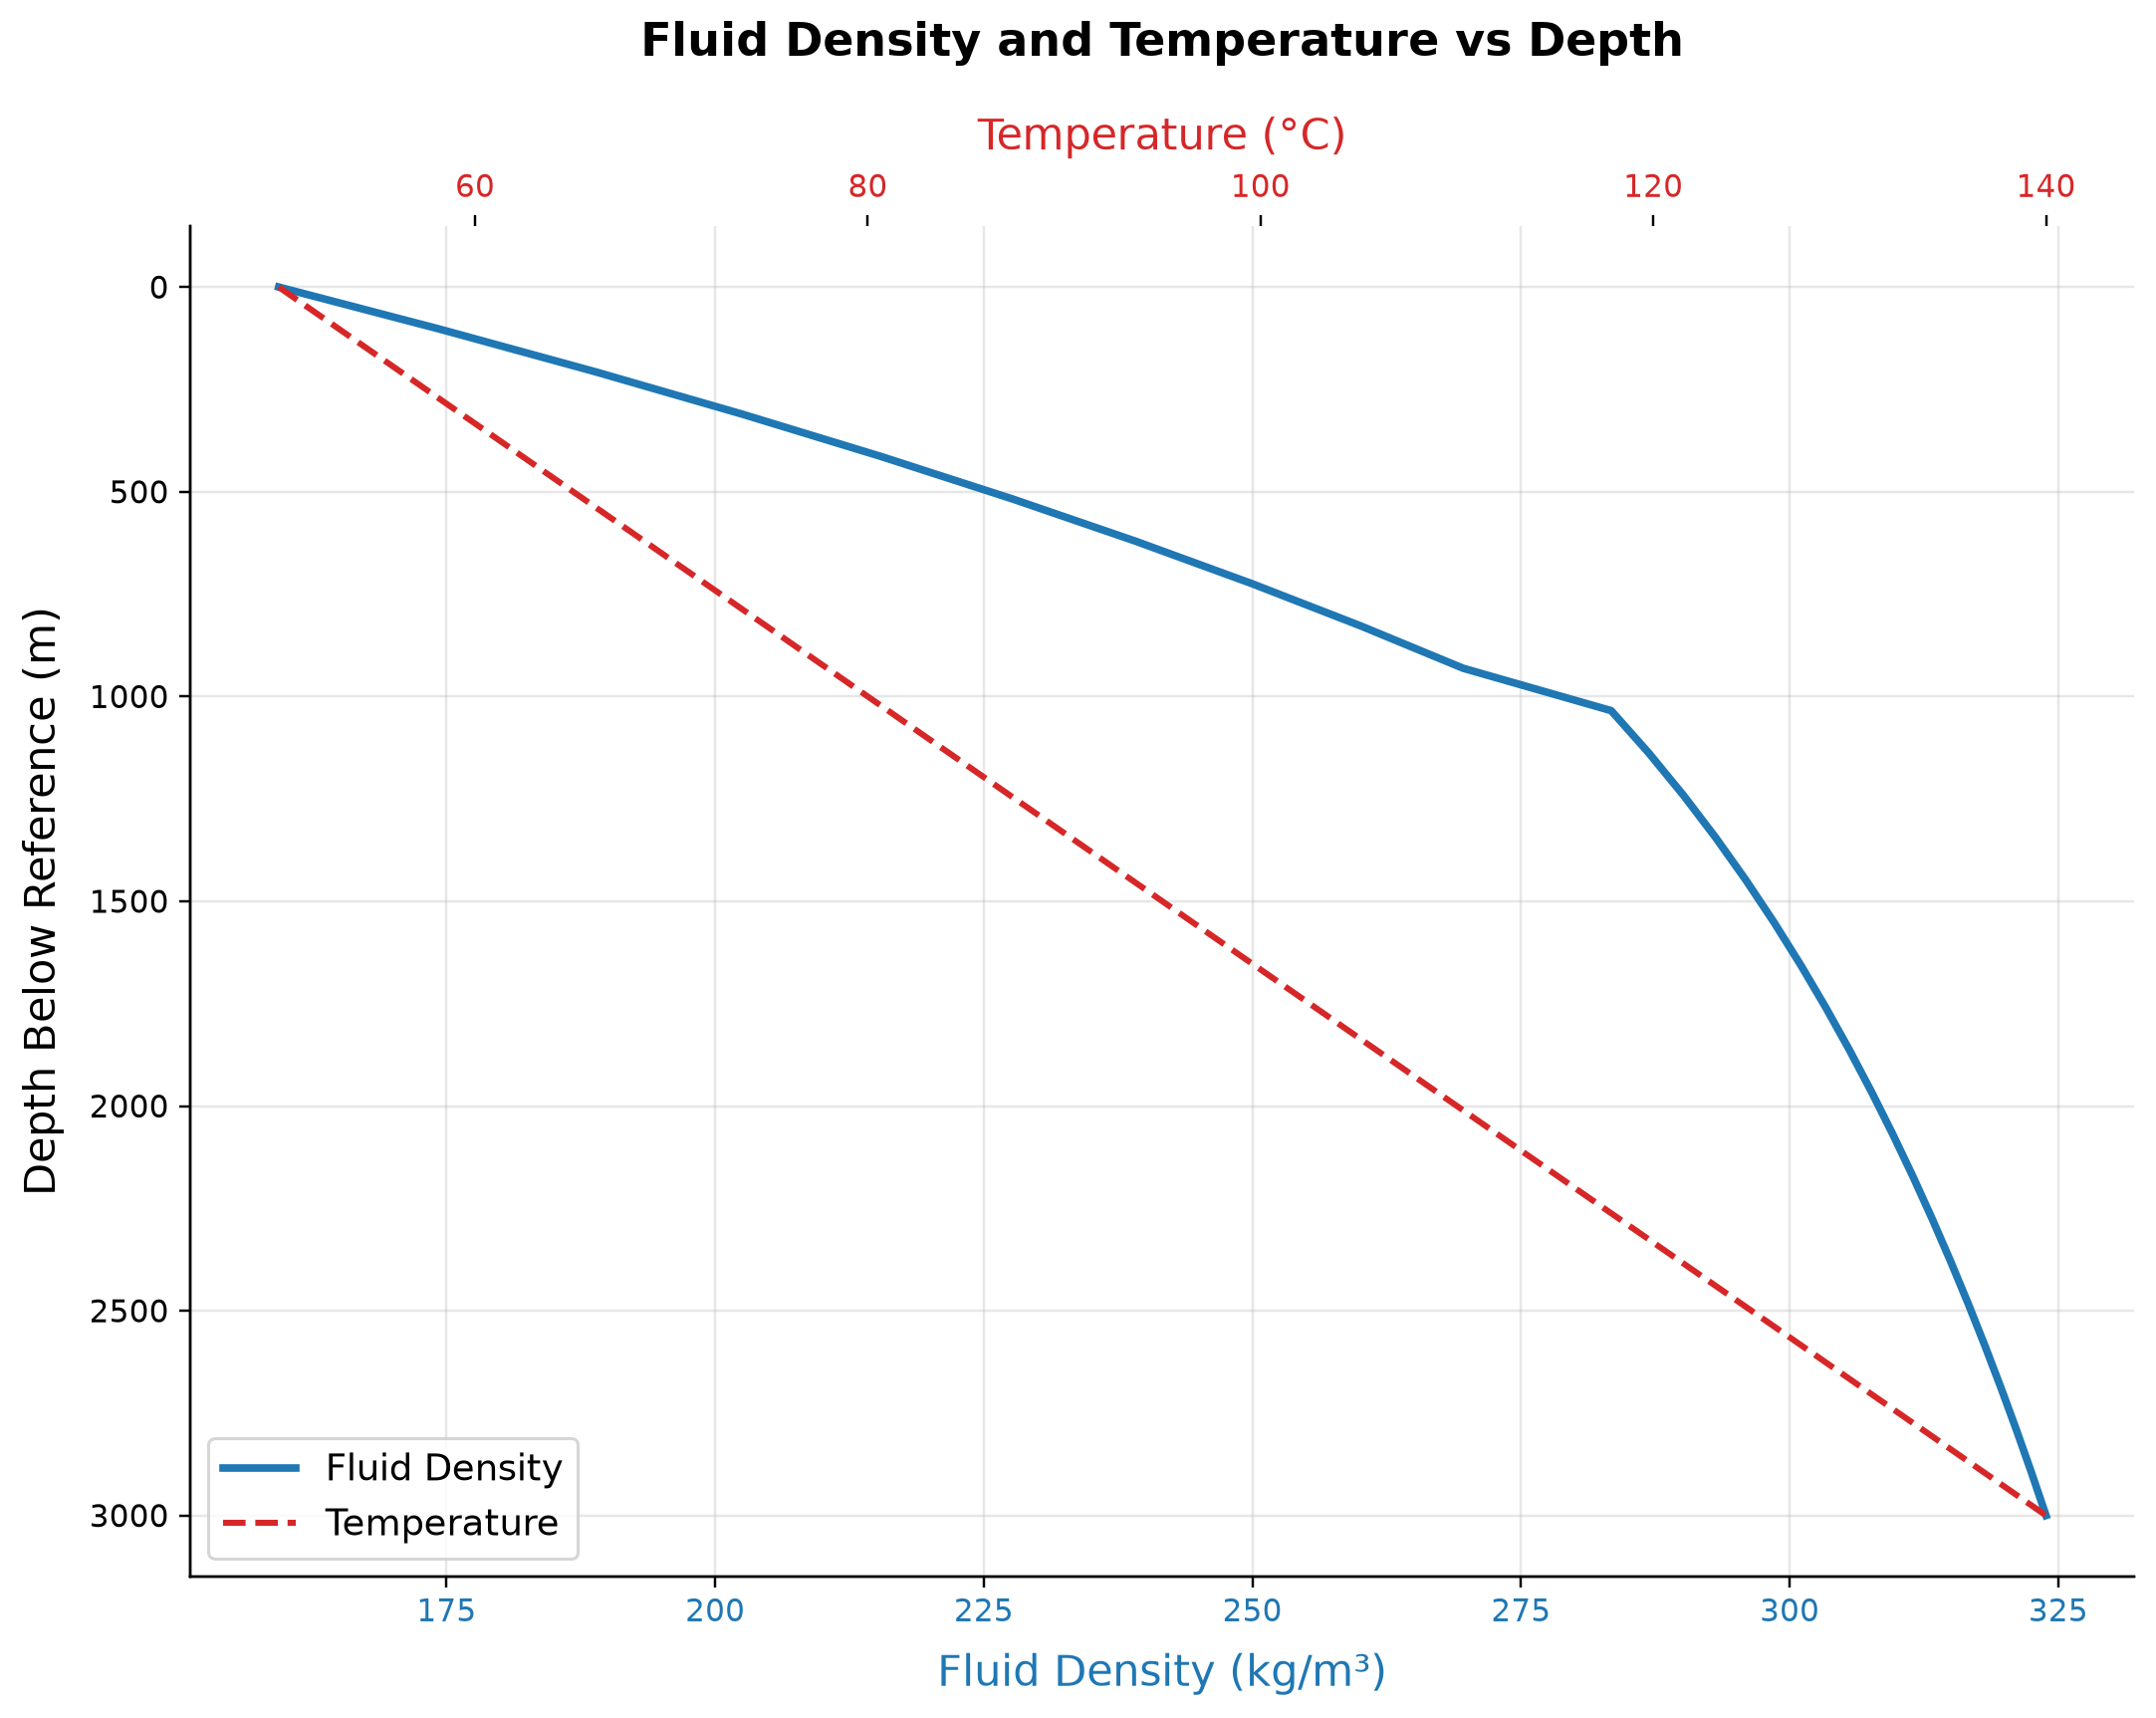

In [6]:
# Depth profile parameters
depths = np.linspace(0, 3000, 30)  # meters below surface reference
T_surface_C = 50.0  # °C at reference depth
P_surface_bara = 100.0  # bara at reference depth
geothermal_gradient = 0.03  # °C/m
hydrostatic_gradient = 0.10  # bar/m; imposed pressure path, not a solved hydrostatic gradient

densities = []
temps = []
press = []

for d in depths:
    T_C = T_surface_C + geothermal_gradient * d
    T_K = 273.15 + T_C
    P_bar = P_surface_bara + hydrostatic_gradient * d
    temps.append(T_C)
    press.append(P_bar)

    fluid_d = fluid.clone()
    fluid_d.setTemperature(T_K)
    fluid_d.setPressure(float(P_bar))
    ops_d = ThermodynamicOperations(fluid_d)
    ops_d.TPflash()
    fluid_d.initProperties()
    assert _physics.state(fluid_d, 'calculation_cell_10:fluid_d', candidate=False)

    # Total (mixture) density
    density = fluid_d.getDensity("kg/m3")
    densities.append(density)

fig, ax1 = plt.subplots(figsize=(10, 8))

color1 = 'tab:blue'
ax1.plot(densities, depths, color=color1, linewidth=2.5, label='Fluid Density')
ax1.set_xlabel('Fluid Density (kg/m³)', fontsize=14, color=color1)
ax1.set_ylabel('Depth Below Reference (m)', fontsize=14)
ax1.tick_params(axis='x', labelcolor=color1)
ax1.invert_yaxis()  # Depth increases downward
ax1.grid(True, alpha=0.3)

ax2 = ax1.twiny()
color2 = 'tab:red'
ax2.plot(temps, depths, color=color2, linewidth=2, linestyle='--', label='Temperature')
ax2.set_xlabel('Temperature (°C)', fontsize=14, color=color2)
ax2.tick_params(axis='x', labelcolor=color2)

lines1, labels1 = ax1.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
ax1.legend(lines1 + lines2, labels1 + labels2, fontsize=12, loc='lower left')

ax1.set_title('Fluid Density and Temperature vs Depth', fontsize=15, pad=20)
plt.tight_layout()
plt.savefig(FIGURES_DIR / 'ch04_fig03_density_vs_depth.png', dpi=220, bbox_inches='tight')
plt.show()
print("Figure 3 saved.")


**Executed-figure discussion.** Across the assumed 0–3000 m depth interval, density spans 159.4–323.9 kg/m³ and temperature spans 50.0–140.0 °C.

Depth changes both hydrostatic pressure and temperature; these effects jointly alter fluid density. A constant-density hydrostatic approximation can bias bottom-hole pressure, particularly for compressible or near-saturation fluids. Integrate density over the pressure–temperature path and compare with measured gradients before using the profile for well control or inflow calibration.


## Figure 4: Relative Permeability Curves (Corey Model)

Relative permeability controls multiphase flow in porous media. The Corey model provides
a simple power-law representation:

$$k_{rw} = k_{rw}^{max} \cdot S_e^{n_w}$$
$$k_{ro} = k_{ro}^{max} \cdot (1 - S_e)^{n_o}$$

where $S_e = \frac{S_w - S_{wc}}{1 - S_{wc} - S_{or}}$ is the normalized water saturation.

Figure 4 saved.


ch04_reservoir_figures.ipynb:cell12:43: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown


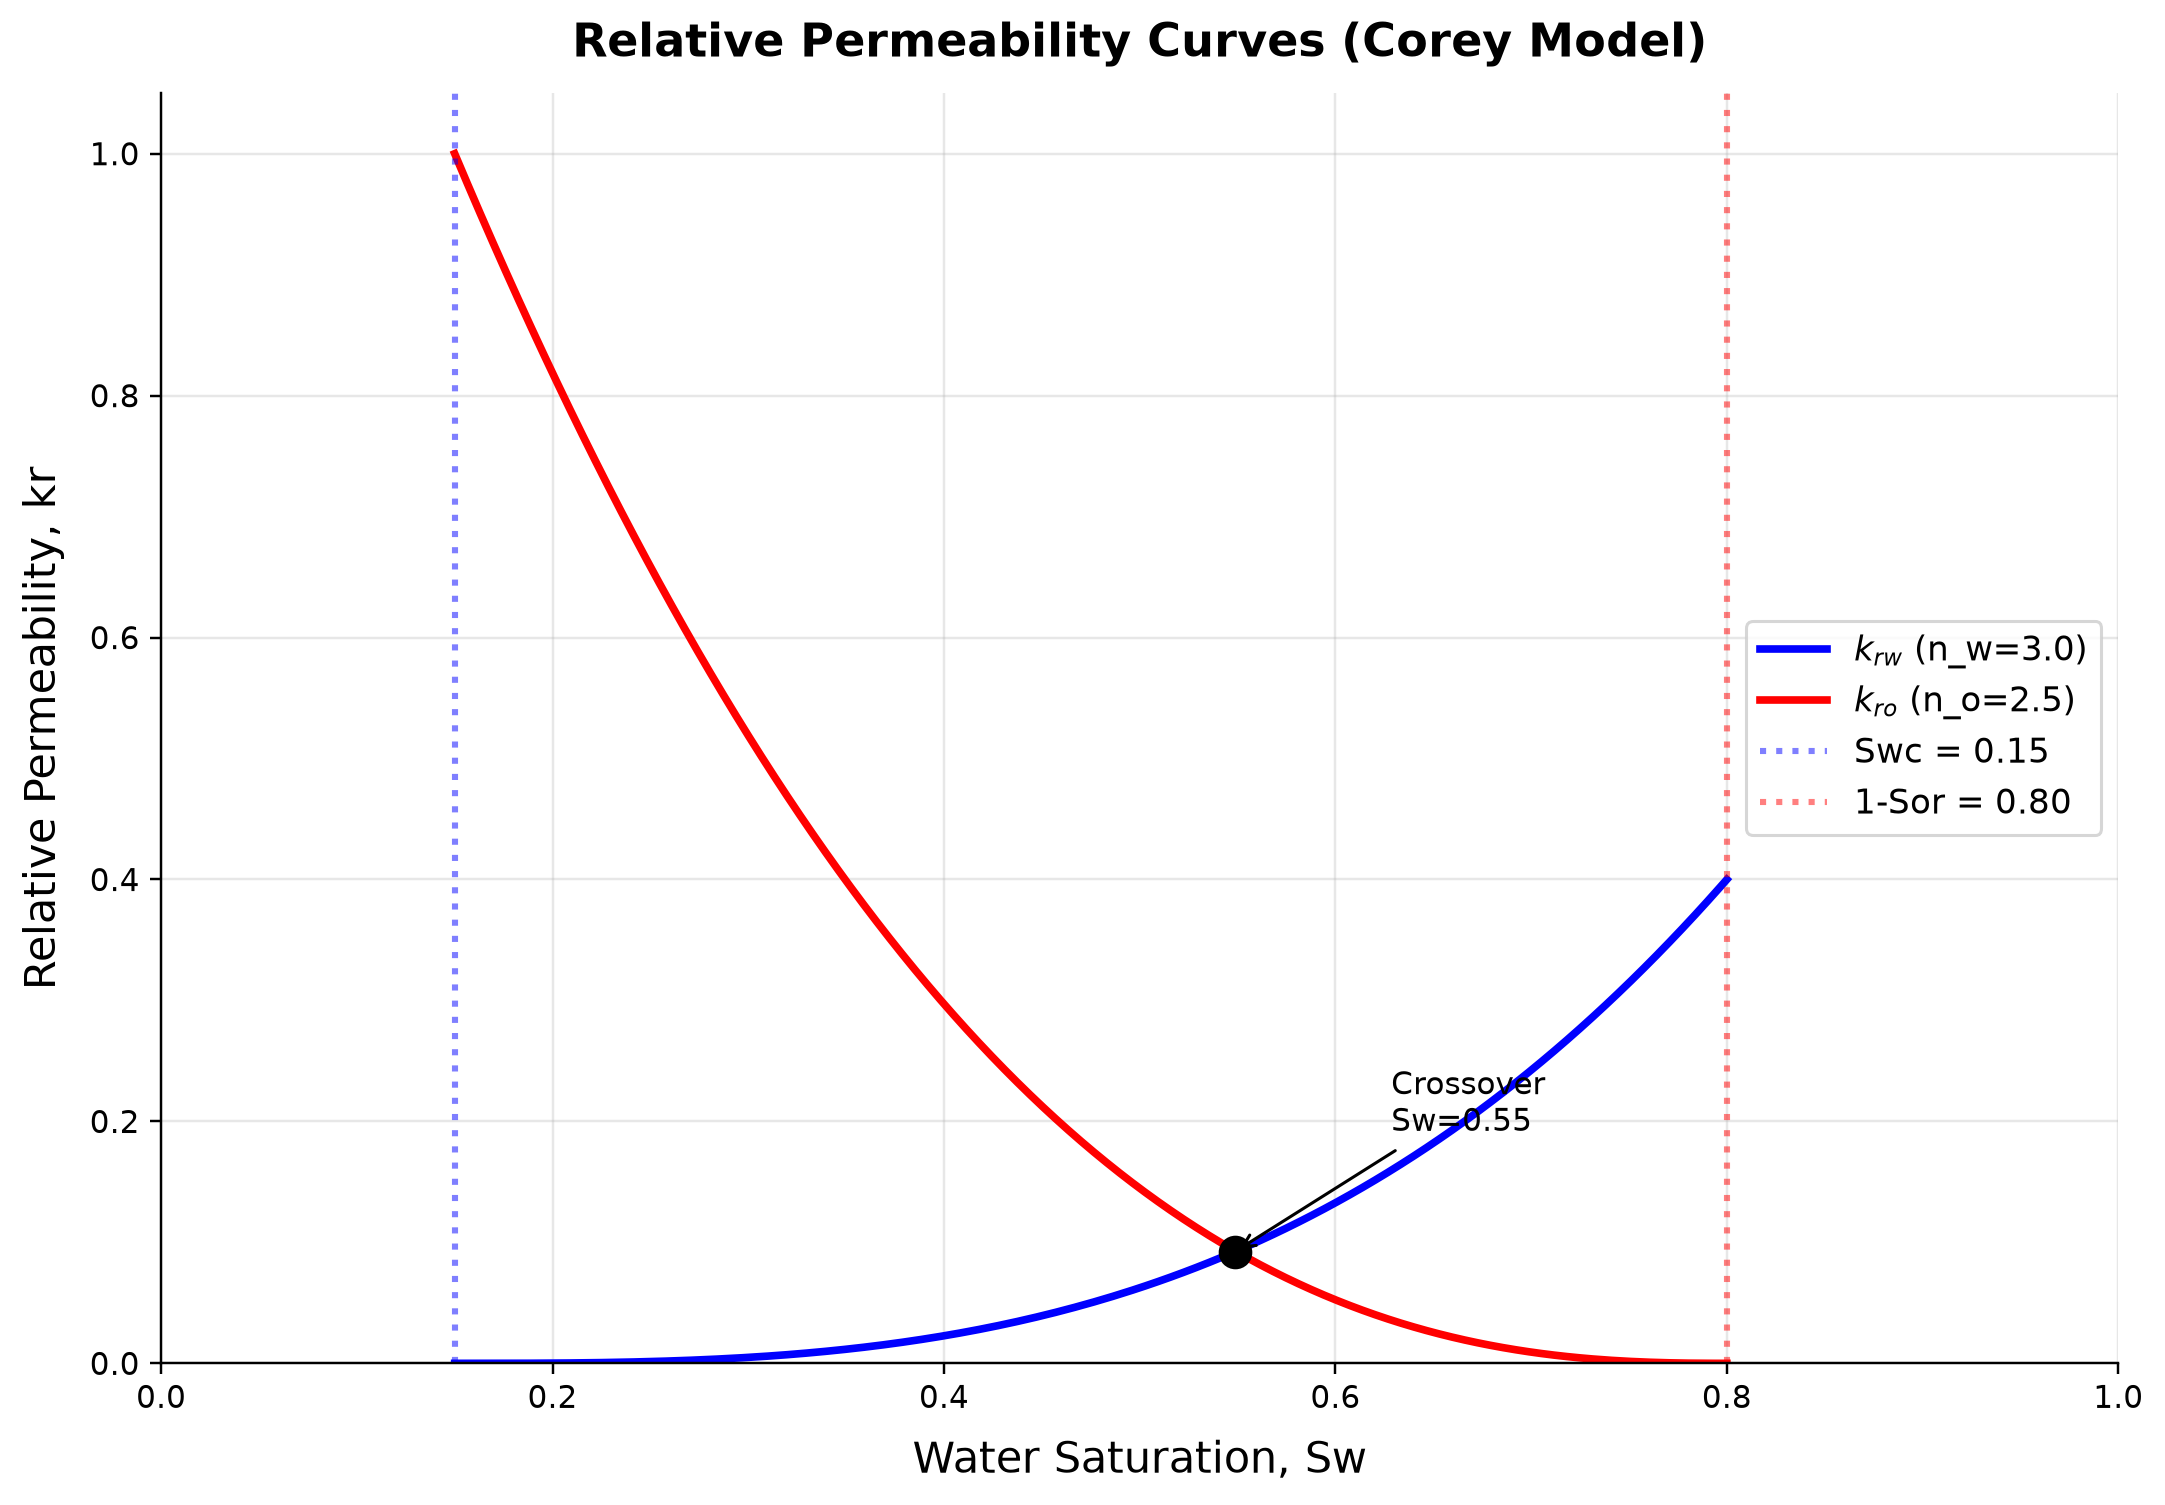

In [7]:
# Corey relative permeability parameters
Swc = 0.15     # Connate water saturation
Sor = 0.20     # Residual oil saturation
n_w = 3.0      # Water Corey exponent
n_o = 2.5      # Oil Corey exponent
kr_w_max = 0.4  # Maximum water relative permeability
kr_o_max = 1.0  # Maximum oil relative permeability (at Swc)

# Water saturation range
Sw = np.linspace(Swc, 1.0 - Sor, 200)

# Normalized saturation
Se = np.clip((Sw - Swc) / (1.0 - Swc - Sor), 0.0, 1.0)

# Corey model
kr_w = kr_w_max * Se**n_w
kr_o = kr_o_max * (1.0 - Se)**n_o

fig, ax = plt.subplots(figsize=(10, 7))
ax.plot(Sw, kr_w, 'b-', linewidth=2.5, label=f'$k_{{rw}}$ (n_w={n_w})')
ax.plot(Sw, kr_o, 'r-', linewidth=2.5, label=f'$k_{{ro}}$ (n_o={n_o})')

# Mark key saturations
ax.axvline(x=Swc, color='blue', linestyle=':', alpha=0.5, label=f'Swc = {Swc}')
ax.axvline(x=1.0 - Sor, color='red', linestyle=':', alpha=0.5, label=f'1-Sor = {1-Sor:.2f}')

# Crossover point
cross_idx = np.argmin(np.abs(kr_w - kr_o))
ax.plot(Sw[cross_idx], kr_w[cross_idx], 'ko', markersize=10)
ax.annotate(f'Crossover\nSw={Sw[cross_idx]:.2f}', xy=(Sw[cross_idx], kr_w[cross_idx]),
            xytext=(Sw[cross_idx]+0.08, kr_w[cross_idx]+0.1), fontsize=10,
            arrowprops=dict(arrowstyle='->', color='black'))

ax.set_xlabel('Water Saturation, Sw', fontsize=14)
ax.set_ylabel('Relative Permeability, kr', fontsize=14)
ax.set_title('Relative Permeability Curves (Corey Model)', fontsize=15)
ax.legend(fontsize=11, loc='center right')
ax.grid(True, alpha=0.3)
ax.set_xlim(0, 1)
ax.set_ylim(0, 1.05)
plt.tight_layout()
plt.savefig(FIGURES_DIR / 'ch04_fig04_rel_perm_curves.png', dpi=220, bbox_inches='tight')
plt.show()
print("Figure 4 saved.")


**Executed-figure discussion.** $k_{rw}$ (n_w=3.0): relative permeability, kr spans 0–0.4 across the plotted cases. $k_{ro}$ (n_o=2.5): relative permeability, kr spans 0–1 across the plotted cases.

The Corey curves allocate effective flow capacity between phases according to saturation, residual saturation and fitted exponents. Their endpoints and curvature can control water breakthrough and mobility predictions; the plotted curves are constitutive assumptions rather than EOS results. Replace the illustrative parameters with rock-type-specific core data and examine hysteresis and endpoint uncertainty in reservoir forecasts.


## Summary

This chapter demonstrated key reservoir engineering concepts:

1. **IPR Curves**: The PI model gives a linear IPR while Vogel accounts for two-phase flow effects below the bubble point, yielding a curved relationship. Selecting the appropriate model depends on whether the well flows above or below the saturation pressure.

2. **GOR vs Pressure**: NeqSim flash calculations show how gas-oil ratio changes as reservoir pressure depletes. This is critical for predicting surface facility requirements and production profiles.

3. **Density vs Depth**: The fluid density profile with depth is computed using NeqSim's equation of state, accounting for both temperature and pressure gradients. This is essential for wellbore hydraulics and pressure gradient calculations.

4. **Relative Permeability**: The Corey model provides a conceptual framework for understanding multiphase flow. While modeled analytically here, these curves can be combined with NeqSim's thermodynamic calculations for reservoir simulation workflows.

### NeqSim Integration

NeqSim's SRK equation of state provides accurate PVT properties needed for:
- Generating IPR curves with realistic fluid properties
- Computing phase behavior during depletion (GOR trends)
- Density profiles for wellbore and reservoir calculations
- Fluid characterization inputs to reservoir simulators

## Numerical output and figure provenance
The following table is extracted from the plotted numerical data. Each saved figure has an adjacent CSV and JSON record; missing points remain visible and are not replaced by interpolated results. Extrema summarize the sampled operating envelope, and are not independent validation of the model.


In [8]:
figure_results = export_figure_summary(NOTEBOOK_PATH)
print(figure_results.to_string(index=False, float_format=lambda value: f'{value:.6g}'))


                         Figure  Panel                  Series                           Output / unit  Minimum  Maximum  Finite points  Missing points
      ch04_fig01_ipr_curves.png      1       PI Model (linear) Bottomhole Flowing Pressure, Pwf (bara)        0      300            200               0
      ch04_fig01_ipr_curves.png      1 Vogel Model (two-phase) Bottomhole Flowing Pressure, Pwf (bara)        0      300            200               0
      ch04_fig01_ipr_curves.png      1                 Curve 3 Bottomhole Flowing Pressure, Pwf (bara)        0        0              2               0
 ch04_fig02_gor_vs_pressure.png      1               Molar GOR       Molar GOR (gas moles / oil moles)  6.00081  62.5096             29              21
ch04_fig03_density_vs_depth.png      1           Fluid Density               Depth Below Reference (m)        0     3000             30               0
ch04_fig03_density_vs_depth.png      2             Temperature                          

## Physical verification and its limits
The assertions above test the calculated states and steady-state conservation laws. Rejected operating candidates remain excluded; they do not become synthetic outputs. The chapter-specific checks below state the applicable limits. Independent reference-fluid and analytic benchmarks are recorded separately in `verification/scientific_revision/benchmark_results.json`. Passing these checks does not establish field calibration or an installed equipment rating.


In [9]:
from chapter_specific_checks import validate_chapter
assert validate_chapter(_physics, globals())
assert _physics.finish()


Physics verification: 74 distinct checks, 1406 evaluations; 0 rejected nonphysical candidates.


## Physical verification and scope

PI/Vogel endpoints and Corey saturation bounds. Inflow and relative-permeability curves are specified correlations; imposed depth gradients are not a coupled hydrostatic solution.

The final code cell checks the computed cases against explicit physical, analytical or constraint criteria. A passed conservation check establishes internal consistency; it does not establish field accuracy. Independent reference values, actual model results, units, acceptance tolerances and source provenance are retained in the [benchmark notebook](../../../verification/scientific_revision/36_benchmark_validation.ipynb), [benchmark results](../../../verification/scientific_revision/benchmark_results.json) and [chapter validation ledger](../../../verification/scientific_revision/notebook_physics_review.md).
